# Statistics Foundations

## 1. Exploration (Exercises)

### 1.1 Abalone

The [Abalone](https://archive.ics.uci.edu/dataset/1/abalone) dataset contains measurements of over 4000 abalone (sea snails).

You can find the data in `data/abalone.csv`

Load the data into a `pandas` dataframe.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

abalone = pd.read_csv('data/abalone.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'data/abalone.csv'

What size is this sample?

In [ ]:
len(abalone)

4177

Are there any missing values in the data?

In [ ]:
abalone.isna().sum()

# shows zero missing values for all variables

Sex         0
Rings       0
Length      0
Diameter    0
Height      0
Weight      0
dtype: int64

Visualise the distribution of the `Weight` variable.

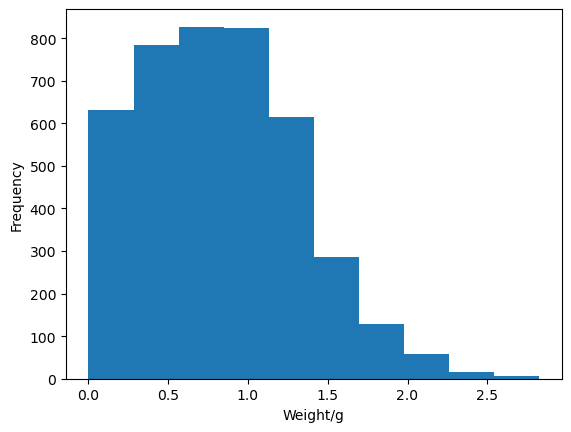

In [ ]:
abalone['Weight'].plot.hist(xlabel='Weight/g')
plt.show()

Now make a visualisation to compare the distribution of `Weight` for the three values of `Sex` (M=male/F=female/I=infant).

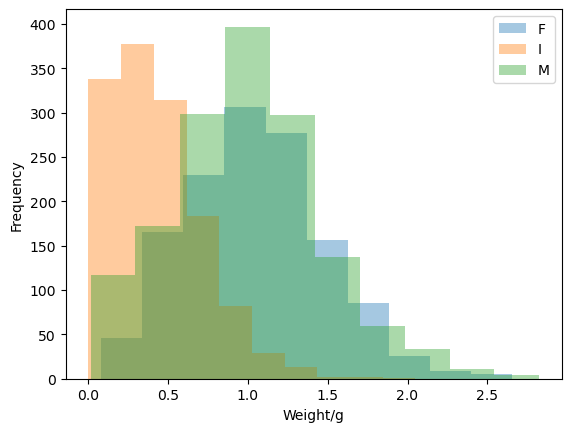

In [ ]:
# Overlaid histograms are OK but a bit tricky to read when
# there is a lot of overlap

abalone.groupby('Sex')['Weight'].plot.hist(alpha=0.4, 
                                            xlabel='Weight/g',
                                            legend=True)
plt.show()

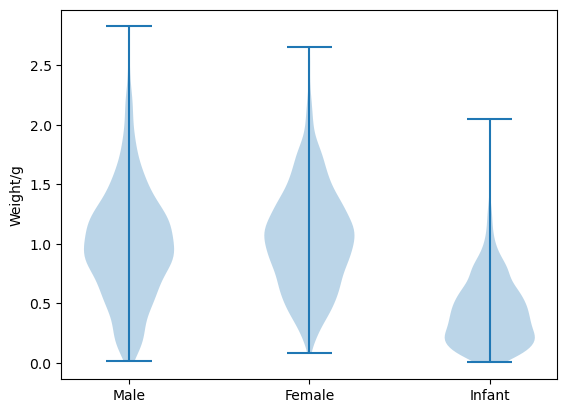

In [ ]:
# Violin plots give a clearer comparison

sex_m=abalone[abalone['Sex'] == "M"].dropna()
sex_f=abalone[abalone['Sex'] == "F"].dropna()
sex_i=abalone[abalone['Sex'] == "I"].dropna()

fig, axs = plt.subplots()
plt.violinplot([sex_m['Weight'].values,
                sex_f['Weight'].values,
                sex_i['Weight'].values])
axs.set_xticks([1,2,3])
axs.set_xticklabels(['Male','Female','Infant'])
axs.set_ylabel("Weight/g")

plt.show()

The variable `Rings` is closely related to the snail's age.

Use a bar chart to visualise the distribution of `Rings`.

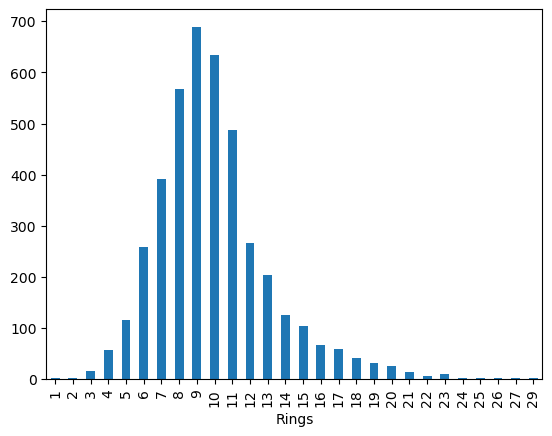

In [ ]:
# The extra sort_index() step is needed to get the bars in numerical order
abalone['Rings'].value_counts() \
    .sort_index() \
    .plot.bar()

plt.show()

Now show how much of each bar is made up of each `Sex`.

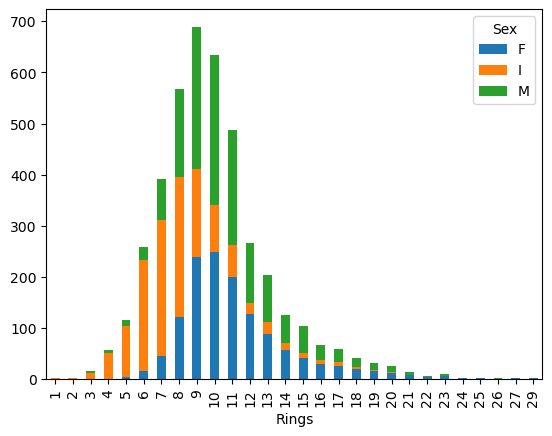

In [ ]:
pd.crosstab(abalone['Rings'], columns=abalone['Sex']) \
    .plot.bar(stacked=True)
plt.show()

Visualise the relationship between `Length` and `Rings`.

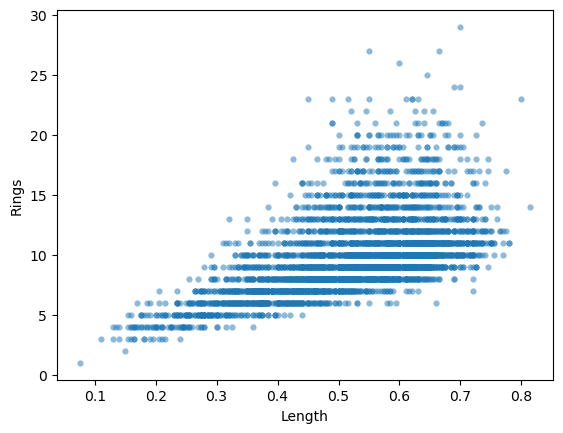

In [ ]:
abalone.plot.scatter(x='Length', 
                      y='Rings',
                      linewidth=0, 
                      alpha=0.5)
plt.show()

### 1.2 MAGIC Gamma Telescope

The [MAGIC](https://archive.ics.uci.edu/dataset/159/magic+gamma+telescope) dataset is a simulated dataset used to investigate the separation of high energy gamma rays from background signals in an atmospheric Cherenkov telescope.

The data can be found in `data/magic04.csv`.

Load the data into a `pandas` dataframe.

In [ ]:
import pandas as pd

magic = pd.read_csv('data/magic04.csv')

How is the distribution of `Alpha` different between signal and background?

*Hint*: in the `class` variable, `'g'` corresponds to a gamma ray (signal) and `'h'` corresponds to a hadron (background).

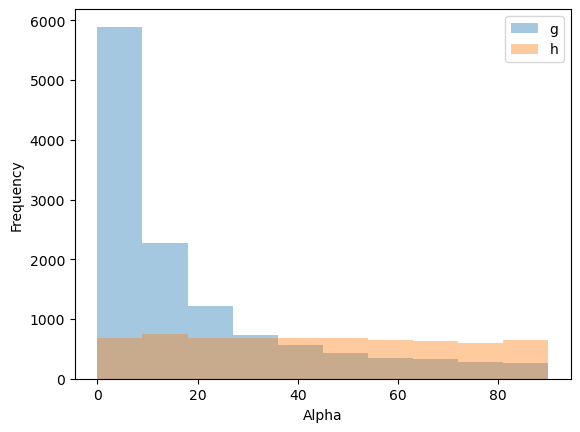

In [ ]:
magic.groupby('class')['Alpha'].plot.hist(alpha=0.4, 
                                            xlabel='Alpha',
                                            legend=True)

plt.show()

# the background shows a roughly uniform distribution whilst
# the signal is strongly skewed to lower values.

Using a `for` loop, compare the signal/background distributions for each of the variables.

*Hint*: The column headers can be obtained using `DataFrame.columns`.

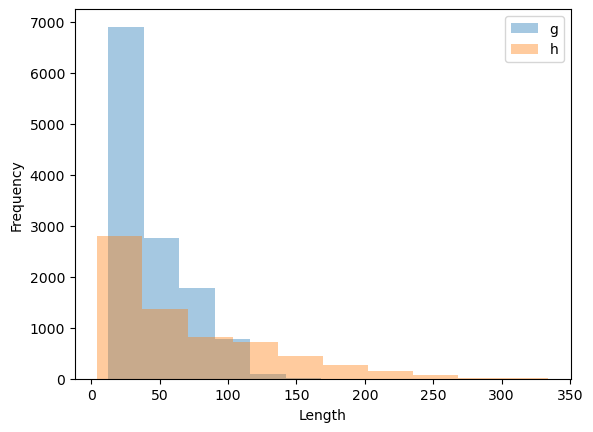

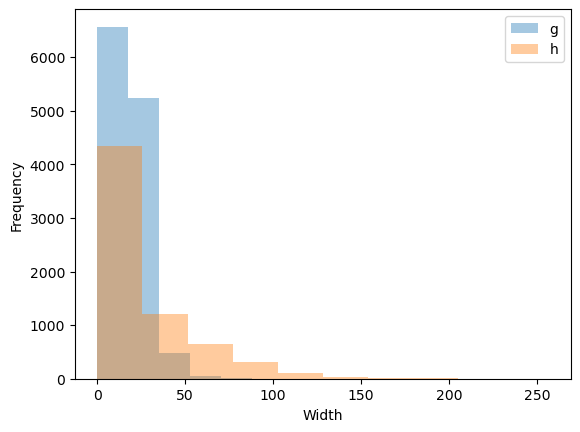

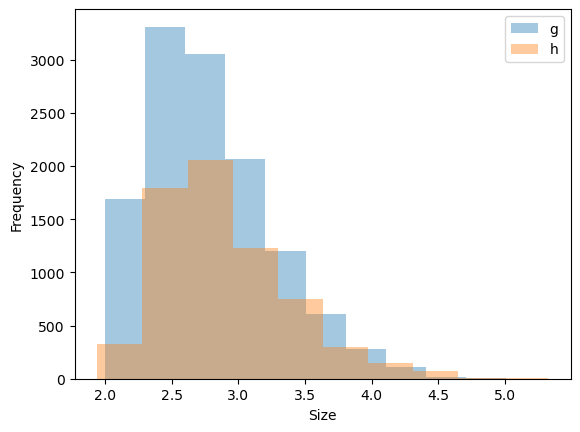

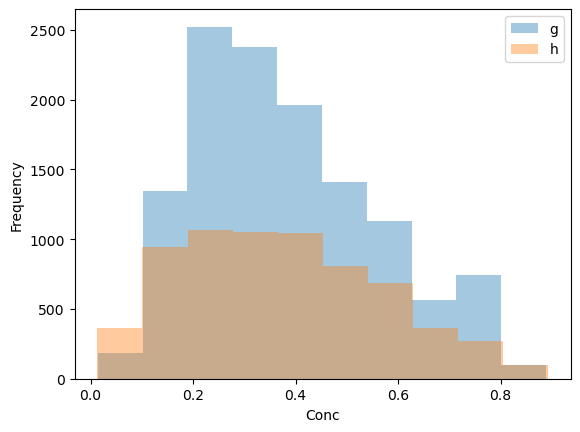

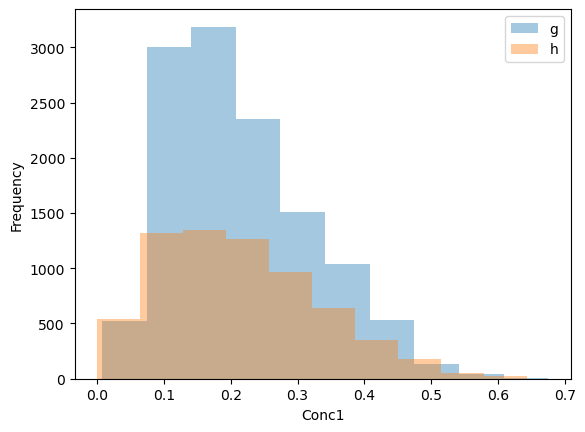

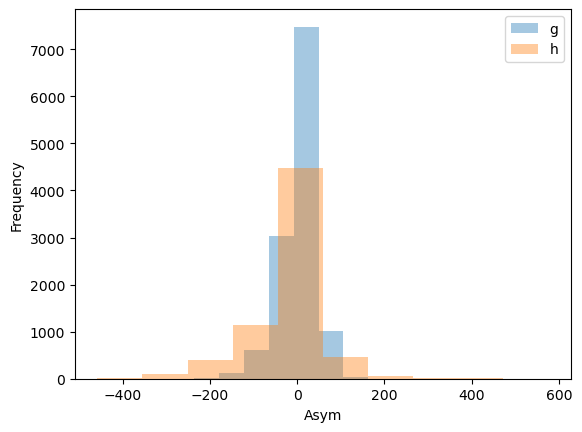

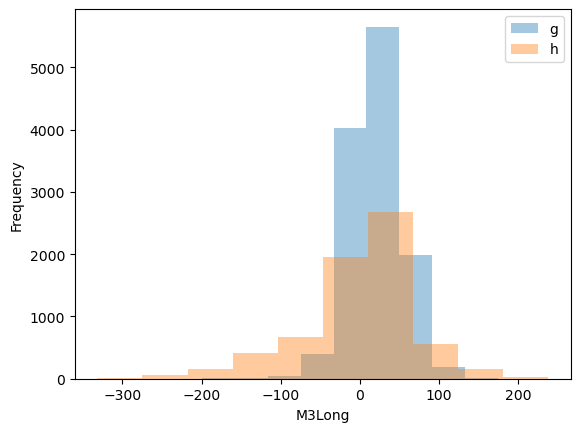

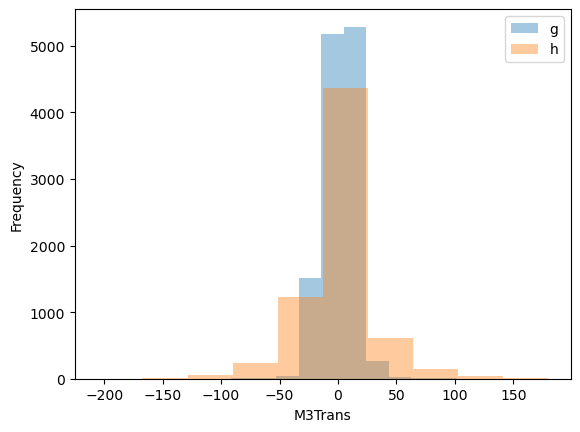

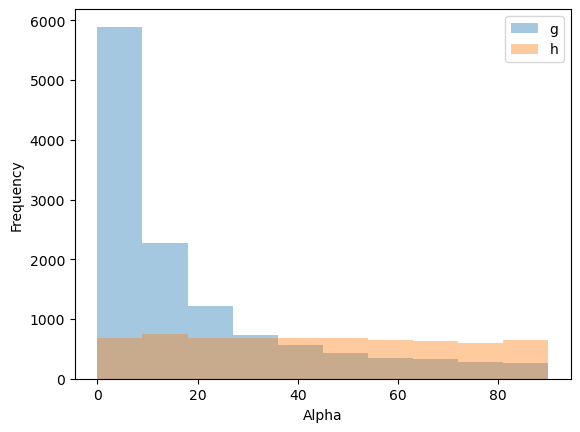

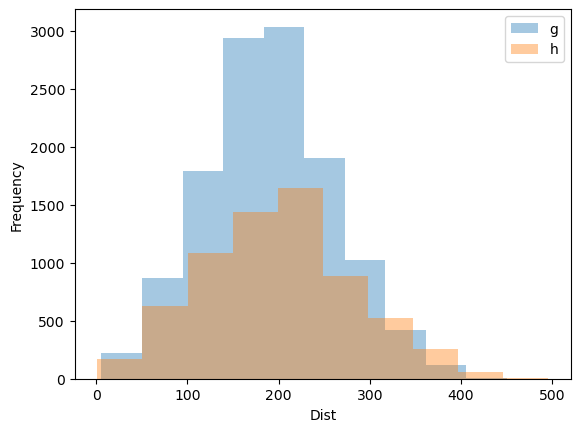

In [ ]:
# discarding the last column, which is the class
for f in magic.columns[:-1]:
    magic.groupby('class')[f].plot.hist(alpha=0.4, 
                                            xlabel=f,
                                            legend=True)
    plt.show()

Which combinations of variables might be useful in distinguishing signal from background?

In [ ]:
# colouring signal as magenta and background as yellow
col = [ 'magenta' if cl == 'g' else 'yellow' for cl in magic['class'] ]

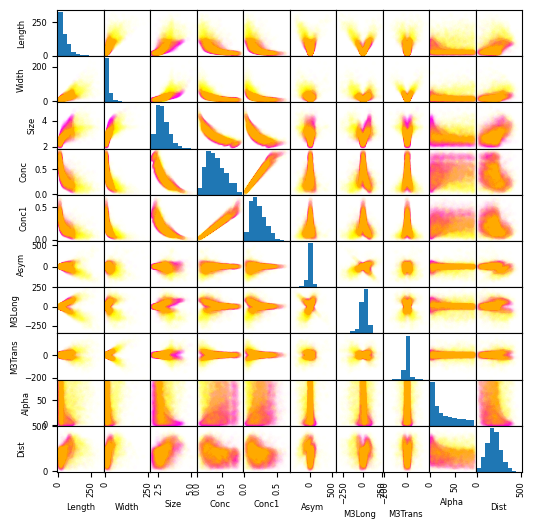

In [ ]:
# There are so many data that we need to turn the alpha right down 
# to be able to see the dense regions for each class
axs = pd.plotting.scatter_matrix(magic, 
                                 figsize=(6, 6), 
                                 c=col, 
                                 alpha=0.01)
for ax in axs.flatten():
    ax.tick_params(labelsize=6)
    ax.xaxis.label.set_size(6)
    ax.yaxis.label.set_size(6)


plt.show()

# There are several joint distributions that show strong differences
# between the two classes (e.g. Size/Width)

### 1.3 Liver Cirrhosis

The file `data/cirrhosis.csv` contains data from a [study](https://archive.ics.uci.edu/dataset/878/cirrhosis+patient+survival+prediction+dataset-1) of liver cirrhosis patients.

The variable `Stage` characterises the stage of the disease.

Which observable variables are most useful for tracking the disease stage of a patient?

In [ ]:
cirrhosis = pd.read_csv('data/cirrhosis.csv')

In [ ]:
stage_labels = [1,2,3,4]
stages = [cirrhosis[cirrhosis['Stage'] == i] for i in stage_labels]

In [ ]:
quantitative_features = ['Age',
                         'Bilirubin',
                         'Cholesterol',
                         'Albumin',
                         'Copper',
                         'Alk_Phos',
                         'SGOT',
                         'Triglicerides',
                         'Platelets',
                         'Prothrombin']

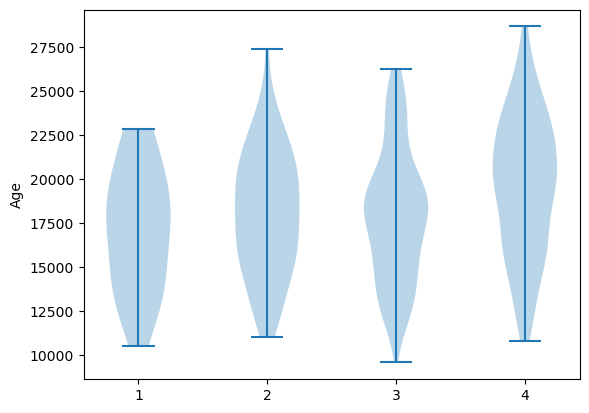

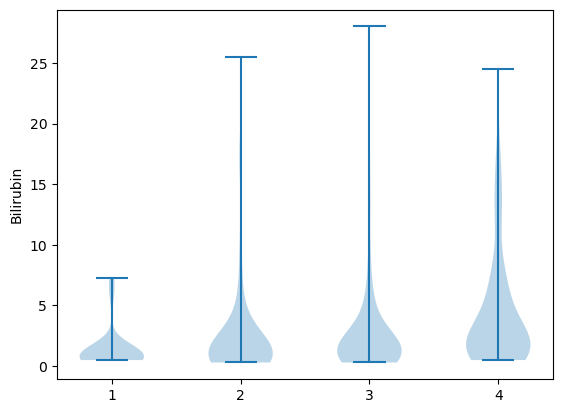

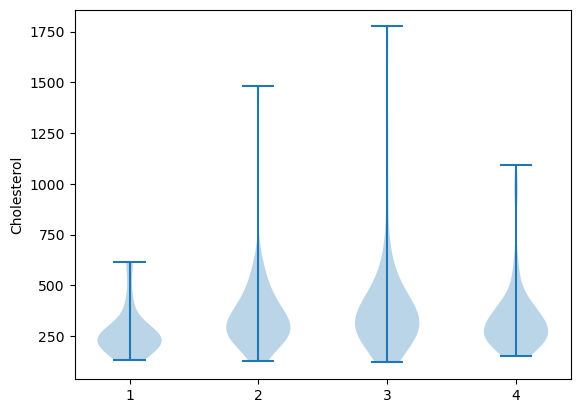

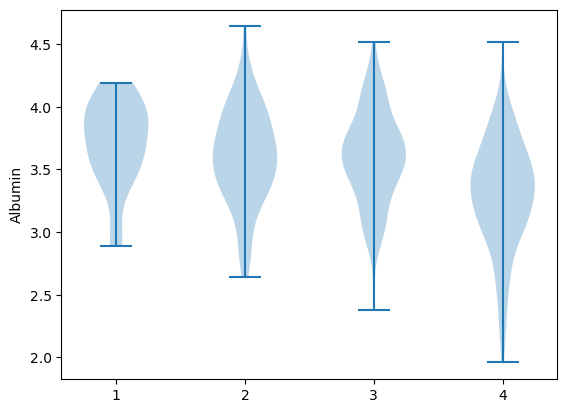

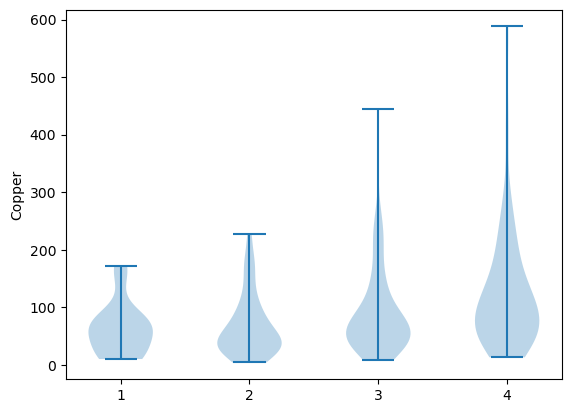

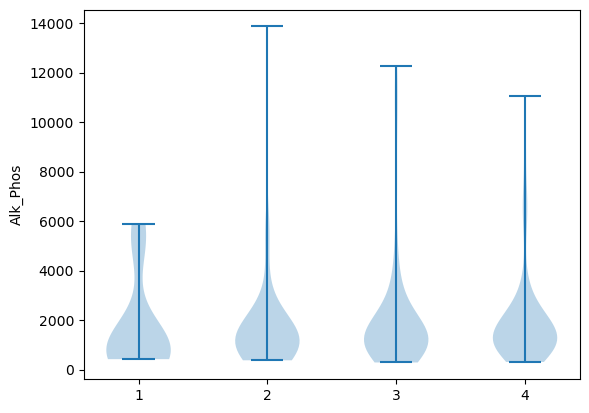

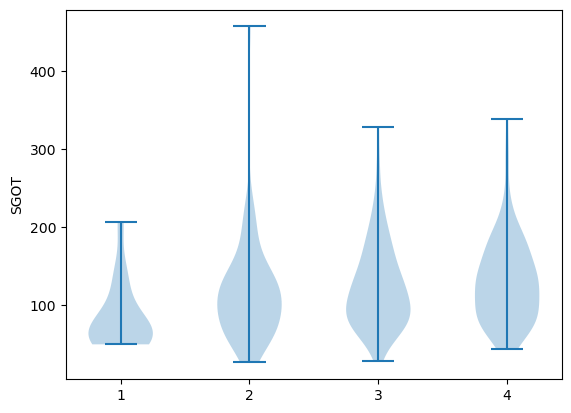

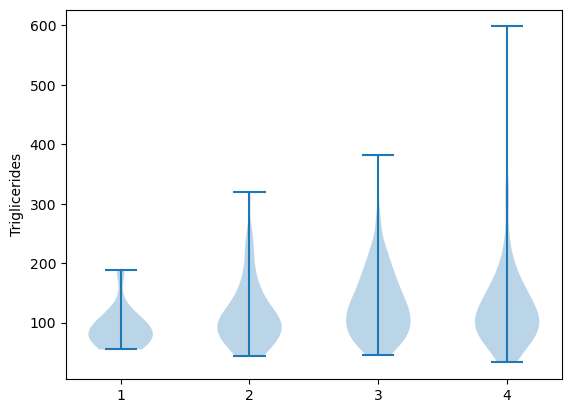

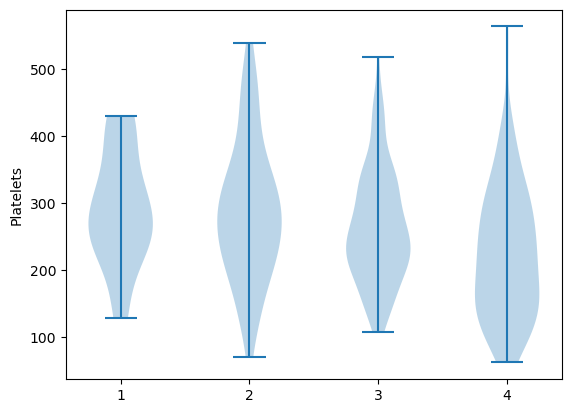

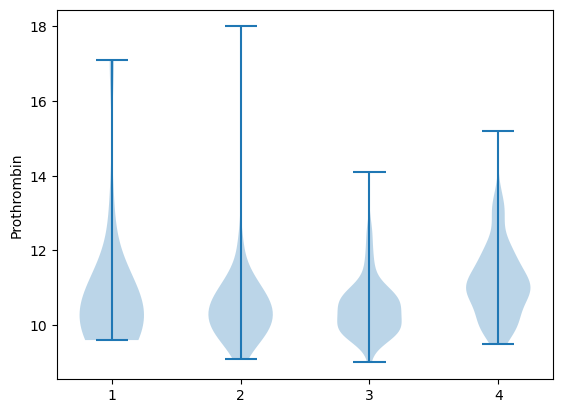

In [ ]:
for f in quantitative_features:
    fig, axs = plt.subplots()
    plt.violinplot([s[f].dropna().values for s in stages])
    axs.set_xticks([1,2,3,4])
    axs.set_xticklabels(stage_labels)
    axs.set_ylabel(f)
    plt.show()

# The albumin distribution seems to shift towards lower values 
# at each stage

In [ ]:
categorical_features = ['Ascites','Hepatomegaly','Spiders']

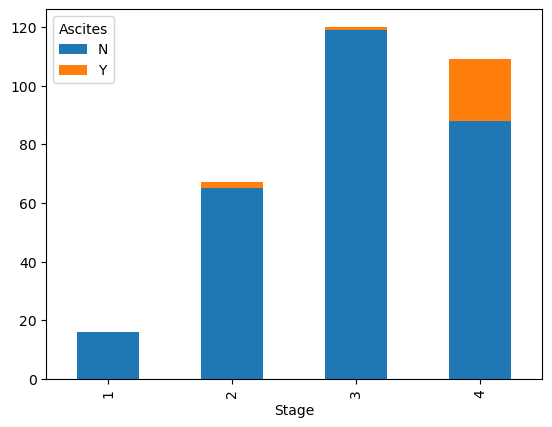

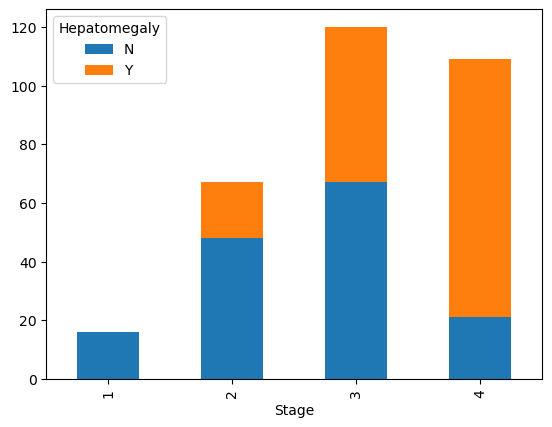

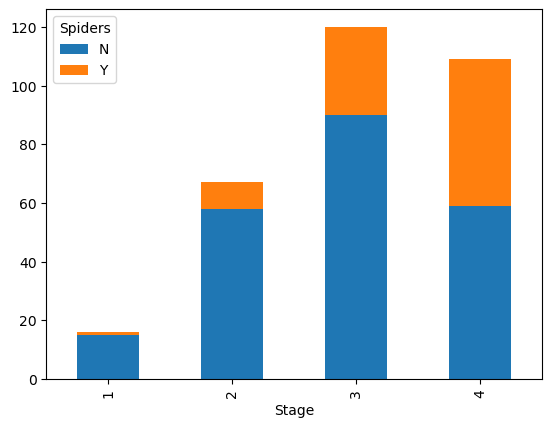

In [ ]:
for f in categorical_features:
    pd.crosstab(cirrhosis['Stage'], columns=cirrhosis[f]) \
        .plot.bar(stacked=True)
    plt.show()


# The presence of spiders and hepatomegaly 
# are both characteristic of more advanced disease.

# Ascites are almost always associated with stage 4.